DECISION TREE

In [1]:
import pandas as pd
import math

In [2]:
# -----------------------------
# Play Tennis Dataset
# -----------------------------
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain',
                'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain',
                'Sunny', 'Overcast', 'Overcast', 'Rain'],

    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool',
                    'Cool', 'Cool', 'Mild', 'Cool', 'Mild',
                    'Mild', 'Mild', 'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal',
                 'Normal', 'Normal', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Strong'],

    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes',
                   'No', 'Yes', 'No', 'Yes', 'Yes',
                   'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

In [3]:
# -----------------------------
# Calculate Entropy
# -----------------------------
def entropy(data, target):

    values = data[target].value_counts()
    total = len(data)

    ent = 0

    for count in values:
        probability = count / total
        ent -= probability * math.log2(probability)

    return ent


In [4]:
# -----------------------------
# Calculate Information Gain
# -----------------------------
def information_gain(data, attribute, target):

    total_entropy = entropy(data, target)

    values = data[attribute].unique()

    weighted_entropy = 0

    for value in values:

        subset = data[data[attribute] == value]

        probability = len(subset) / len(data)

        weighted_entropy += probability * entropy(subset, target)

    gain = total_entropy - weighted_entropy

    return gain

In [5]:
# -----------------------------
# ID3 Algorithm
# -----------------------------
def id3(data, attributes, target):

    # If all examples belong to same class
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    # If no attributes are left
    if len(attributes) == 0:
        return data[target].mode()[0]

    # Calculate Information Gain for all attributes
    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(
            data, attribute, target
        )

    # Select attribute with maximum Information Gain
    best_attribute = max(gains, key=gains.get)

    tree = {best_attribute: {}}

    # Create branches
    for value in data[best_attribute].unique():

        subset = data[data[best_attribute] == value]

        remaining_attributes = [
            attr for attr in attributes
            if attr != best_attribute
        ]

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes,
            target
        )

    return tree


In [6]:
# -----------------------------
# Build Decision Tree
# -----------------------------
attributes = [
    'Outlook',
    'Temperature',
    'Humidity',
    'Wind'
]

target = 'PlayTennis'

tree = id3(df, attributes, target)

print("Decision Tree:")
print(tree)

Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [14]:
# Create LabelEncoder object
le = LabelEncoder()

# Convert all categorical columns into numbers
for column in df.columns:
    df[column] = le.fit_transform(df[column])

In [15]:
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

In [17]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

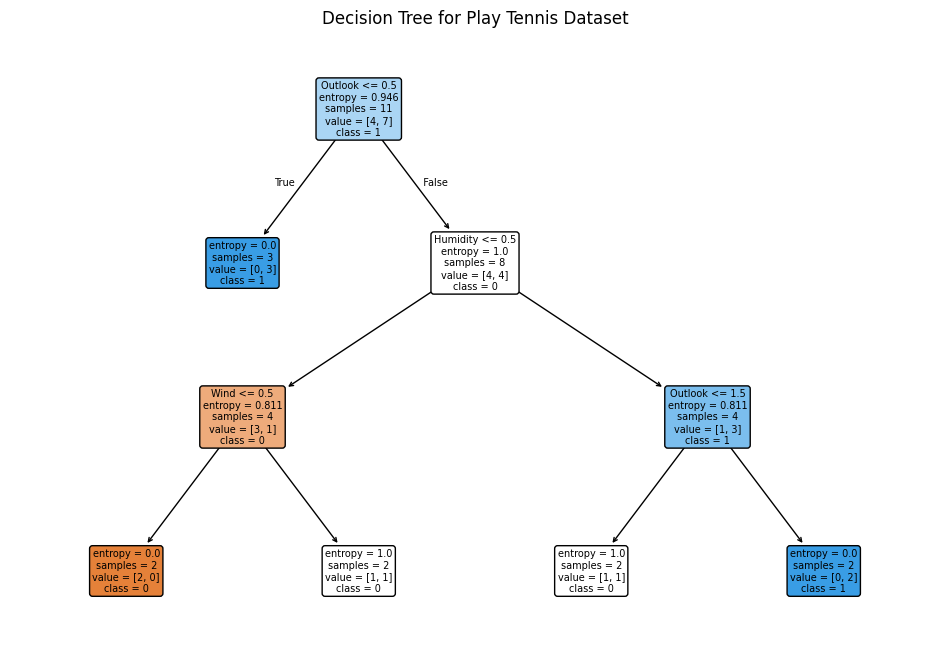

In [19]:
# Make the graphical representation of the decision tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Decision Tree for Play Tennis Dataset")
plt.xlabel("Attributes")
plt.ylabel("Class")
plt.show()